## Import e Features

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from google.colab import drive
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler

drive.mount('/content/drive')

# --- 1. Carregar e Preparar os Dados ---

"""df = pd.read_csv('/content/drive/MyDrive/Faculdade/IC/Códigos/IMUSerial/IMU-Serial---IC/all_Leo_n_Gait_n_Read_ALL_Concatenated_NaN_filled.csv')


print("Formato do Dataset Original:")
print(df['S_leo'].head(200))

"""

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'df = pd.read_csv(\'/content/drive/MyDrive/Faculdade/IC/Códigos/IMUSerial/IMU-Serial---IC/all_Leo_n_Gait_n_Read_ALL_Concatenated_NaN_filled.csv\')\n\n\nprint("Formato do Dataset Original:")\nprint(df[\'S_leo\'].head(200))\n\n'

## Vamos arrumar o dataset


In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_felix0_rot.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_felix1_rot.csv')
df3 = pd.read_csv('/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_sah1_rot.csv')
df4 = pd.read_csv('/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_cell1_rot.csv')
df5 = pd.read_csv('/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_cell1.5_rot.csv')
df6 = pd.read_csv('/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_sah2_rot.csv')


In [ ]:
del df1['classe_prevista']
del df2['classe_prevista']
del df3['classe_prevista']
del df4['classe_prevista']
del df5['classe_prevista']
del df6['classe_prevista']

In [ ]:
dfk = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

In [ ]:
import numpy as np
import pandas as pd
import math


df = dfk
# Essa classe imita EXATAMENTE a sua classe 'Kalman' do C++
class SimpleKalman:
    def __init__(self, process_noise, sensor_noise, estimated_error, initial_value):
        self.Q = process_noise
        self.R = sensor_noise
        self.P = estimated_error
        self.x = initial_value

    def update(self, measurement):
        # 1. Predição
        self.P = self.P + self.Q
        # 2. Correção
        K = self.P / (self.P + self.R)
        self.x = self.x + K * (measurement - self.x)
        self.P = (1 - K) * self.P
        return self.x

# Inicializa os filtros para Roll e Pitch
# (Você pode ajustar 0.01 e 0.1 para ficarem iguais aos valores de Q e R do seu C++)
kalman_roll = SimpleKalman(0.01, 0.1, 1.0, 0.0)
kalman_pitch = SimpleKalman(0.01, 0.1, 1.0, 0.0)

roll_list = []
pitch_list = []

print("Calculando Roll e Pitch com o seu Filtro de Kalman...")

for i in range(len(df)):
    ax = df['ax'].iloc[i]
    ay = df['ay'].iloc[i]
    az = df['az'].iloc[i]

    # 1. Calcula o ângulo bruto usando apenas o Acelerômetro (Trigonometria básica)
    raw_roll = math.degrees(math.atan2(ay, az))
    raw_pitch = math.degrees(math.atan2(-ax, math.sqrt(ay**2 + az**2)))

    # 2. Passa os ângulos brutos pelo Filtro de Kalman
    filtered_roll = kalman_roll.update(raw_roll)
    filtered_pitch = kalman_pitch.update(raw_pitch)

    roll_list.append(filtered_roll)
    pitch_list.append(filtered_pitch)

# Adiciona as novas colunas filtradas ao seu DataFrame
df['roll'] = roll_list
df['pitch'] = pitch_list

print("Sucesso! Colunas 'roll' e 'pitch' adicionadas.")
df.head()

Calculando Roll e Pitch com o seu Filtro de Kalman...
Sucesso! Colunas 'roll' e 'pitch' adicionadas.


,timestamp,ax,ay,az,gx,gy,gz,delay_ms,tempo_s,Fase,Classe_Prevista,roll_k,pitch_k,roll,pitch
0,1774389180948,0.037447,0.656631,-0.189516,3.371300e-14,-2.455060e-13,2.107360e-13,3.28544,0.000,0,NaN,NaN,NaN,96.540650,-2.853729
1,1774389180961,0.043574,0.787795,-0.225500,1.831870e-14,-1.446450e-13,1.097910e-13,3.27889,0.013,0,NaN,NaN,NaN,101.280251,-2.949287
2,1774389180975,0.046064,0.845853,-0.242700,1.265820e-14,-1.036000e-13,7.803180e-14,3.42922,0.027,0,NaN,NaN,NaN,103.058356,-2.967046
3,1774389180989,0.048218,0.876320,-0.252934,9.133700e-15,-8.207110e-14,6.103750e-14,3.28439,0.041,0,NaN,NaN,NaN,104.039158,-2.986092
4,1774389181003,0.049952,0.896710,-0.258114,7.150210e-15,-6.851710e-14,5.061430e-14,3.63421,0.055,0,NaN,NaN,NaN,104.638822,-3.009304


In [ ]:
dfk['Fase'] = dfk['Fase'].replace({
    'Heel-strike': 1,
    'Foot-flat': 2,
    'Heel-off': 3,
    'Toe-off': 4,
    'Swing': 5,
    'Desconhecida': 0
})

In [ ]:
dfk

,timestamp,ax,ay,az,gx,gy,gz,delay_ms,tempo_s,Fase,Classe_Prevista,roll_k,pitch_k,roll,pitch
0,1774389180948,0.037447,0.656631,-0.189516,3.371300e-14,-2.455060e-13,2.107360e-13,3.28544,0.000,0,NaN,NaN,NaN,96.540650,-2.853729
1,1774389180961,0.043574,0.787795,-0.225500,1.831870e-14,-1.446450e-13,1.097910e-13,3.27889,0.013,0,NaN,NaN,NaN,101.280251,-2.949287
2,1774389180975,0.046064,0.845853,-0.242700,1.265820e-14,-1.036000e-13,7.803180e-14,3.42922,0.027,0,NaN,NaN,NaN,103.058356,-2.967046
3,1774389180989,0.048218,0.876320,-0.252934,9.133700e-15,-8.207110e-14,6.103750e-14,3.28439,0.041,0,NaN,NaN,NaN,104.039158,-2.986092
4,1774389181003,0.049952,0.896710,-0.258114,7.150210e-15,-6.851710e-14,5.061430e-14,3.63421,0.055,0,NaN,NaN,NaN,104.638822,-3.009304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28178,1774299970886,-0.055897,0.967048,0.104454,-8.023190e-01,1.563730e-01,1.025320e-01,3.23837,96.390,5,NaN,NaN,NaN,83.467578,3.880274
28179,1774299970899,-0.058513,0.991828,0.100121,-8.613170e-01,1.416280e-01,1.130770e-01,3.24504,96.403,5,NaN,NaN,NaN,83.675105,3.739515
28180,1774299970912,-0.059211,1.015490,0.094440,-9.124630e-01,1.279080e-01,1.250990e-01,3.24084,96.416,5,NaN,NaN,NaN,83.948424,3.626911
28181,1774299970926,-0.059963,1.040540,0.087320,-9.568730e-01,1.136550e-01,1.369700e-01,3.24547,96.430,5,NaN,NaN,NaN,84.287376,3.534978


In [ ]:
print(dfk['Fase'].value_counts())

Fase
2    8081
1    5515
5    5371
3    4757
4    3277
0    1120
0      62
Name: count, dtype: int64


In [10]:

# --- 2. Feature Engineering com Janela Deslizante ---

# Parâmetros da janela
WINDOW_SIZE = 30  # 22 amostras
STEP = 5         # Sobreposição de 40 amostras
df = dfk
segments = []
labels = []

# Iterar sobre o dataframe com a janela deslizante
for i in range(0, len(df) - WINDOW_SIZE, STEP):
    window = df.iloc[i : i + WINDOW_SIZE]

    # A label da janela será a fase mais comum (moda) naquele segmento
    label = window['Fase'].mode()[0]

    # Extrair features para cada eixo (ax, ay, ..., gz)
    # Extrair features para cada eixo NA ORDEM EXATA DO C++ (ax, ay, az, gx, gy, gz)
    features = []
    # ATENÇÃO: Garanta que esta ordem é a mesma que entra no deque do seu C++!
    for axis in ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'roll', 'pitch']:
        signal = window[axis].values # .values converte para numpy array (mais fácil de pegar index)

        # Tem que ser EXATAMENTE a mesma ordem do C++
        features.append(signal.mean())        # 0: Mean
        features.append(signal.std(ddof=0))   # 1: StdDev (ddof=0 imita a divisão por N do seu C++)
        features.append(signal[0])            # 2: Front
        features.append(signal[-1])           # 3: Back
        features.append(signal.min())         # 4: Min
        features.append(signal.max())         # 5: Max
        features.append(signal[-1] - signal[0]) # 6: Range (Back - Front)

    segments.append(features)
    labels.append(label)

# Converter para numpy array
X = np.array(segments)
y = np.array(labels)

print(f"\nFormato dos dados após Feature Engineering: {X.shape}")
print(f"Número de janelas (exemplos): {X.shape[0]}")
print(f"Número de features por janela: {X.shape[1]}")

NameError: name 'dfk' is not defined

## Treinamento com XGBoost

In [ ]:
"""
# --- PONTO IMPORTANTE PARA XGBOOST: Codificação das Labels ---
# O XGBoost espera que as classes (labels) sejam números inteiros começando de 0 (0, 1, 2, ...).
# Se suas labels já estão nesse formato, ótimo. Se não, o LabelEncoder resolve.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# --- 3. Divisão e Normalização dos Dados ---
# Usamos y_encoded a partir de agora
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=56, stratify=y_encoded)

scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)"""

'\n# --- PONTO IMPORTANTE PARA XGBOOST: Codificação das Labels ---\n# O XGBoost espera que as classes (labels) sejam números inteiros começando de 0 (0, 1, 2, ...).\n# Se suas labels já estão nesse formato, ótimo. Se não, o LabelEncoder resolve.\nle = LabelEncoder()\ny_encoded = le.fit_transform(y)\n\n# --- 3. Divisão e Normalização dos Dados ---\n# Usamos y_encoded a partir de agora\nX_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=56, stratify=y_encoded)\n\nscaler = StandardScaler()\n#X_train_scaled = scaler.fit_transform(X_train)\n#X_test_scaled = scaler.transform(X_test)'

In [ ]:
# --- 1. Codificação das Labels ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Guardamos as classes numéricas originais para evitar erros no relatório
classes_existentes = np.unique(y_encoded)
class_names_str = [str(c) for c in le.inverse_transform(classes_existentes)]

# --- 2. Divisão Cronológica (Treino, Validação e Teste) ---
# CRÍTICO: shuffle=False para não vazar dados do futuro em séries temporais!
X_temp, X_test, y_temp, y_test = train_test_split(X, y_encoded, test_size=0.12, shuffle=False)

# Dos 90% restantes, tiramos uma fatia para Validação
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.12, shuffle=False)

print(f"Amostras de Treino: {len(X_train)} | Validação: {len(X_val)} | Teste: {len(X_test)}")

# --- 3. Loss Customizada (Pesos Manuais por Classe) ---
pesos_por_classe = {
    0: 1.0,  # desconhecida
    1: 1.5,  # heel-strike
    2: 2.5,  # foot-flat
    3: 3.0,  # heel-off
    4: 10.0, # toe-off
    5: 1.5   # swing
}

# Mapeia os pesos para cada amostra do conjunto de treino
pesos_treino = np.array([pesos_por_classe[classe] for classe in y_train])

# --- 4. Configuração do XGBoost ---
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    n_estimators=200,
    learning_rate=0.01,
    max_depth=4,
    gamma=1,
    max_delta_step=1,
    reg_lambda=2.0,
    eval_metric='mlogloss',
    random_state=56
)

print("\nIniciando treinamento do XGBoost...")

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=pesos_treino,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)
print("Treinamento concluído!")

# --- 6. Previsões ---
y_val_pred = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)

print(f"\nAcurácia na Validação: {accuracy_score(y_val, y_val_pred):.2f}")
print(f"Acurácia no Teste Final: {accuracy_score(y_test, y_test_pred):.2f}")

print("\nRelatório de Classificação (TESTE):")
# Corrigido: Passando labels explicitamente para evitar erro de dimensões se uma classe sumir no split
print(classification_report(y_test, y_test_pred, labels=classes_existentes, target_names=class_names_str))

Amostras de Treino: 4360 | Validação: 595 | Teste: 676

Iniciando treinamento do XGBoost...
[0]	validation_0-mlogloss:1.88491	validation_1-mlogloss:1.88552
[50]	validation_0-mlogloss:1.43353	validation_1-mlogloss:1.59352
[100]	validation_0-mlogloss:1.09580	validation_1-mlogloss:1.25800
[150]	validation_0-mlogloss:0.85592	validation_1-mlogloss:1.03851
[199]	validation_0-mlogloss:0.68965	validation_1-mlogloss:0.88640
Treinamento concluído!

Acurácia na Validação: 0.79
Acurácia no Teste Final: 0.78

Relatório de Classificação (TESTE):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.62      0.99      0.76       160
           2       0.90      0.83      0.87       168
           3       0.84      0.45      0.58       121
           4       0.68      0.80      0.74        71
           5       1.00      0.75      0.86       156

    accuracy                           0.78       676
   macro avg       0.67     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

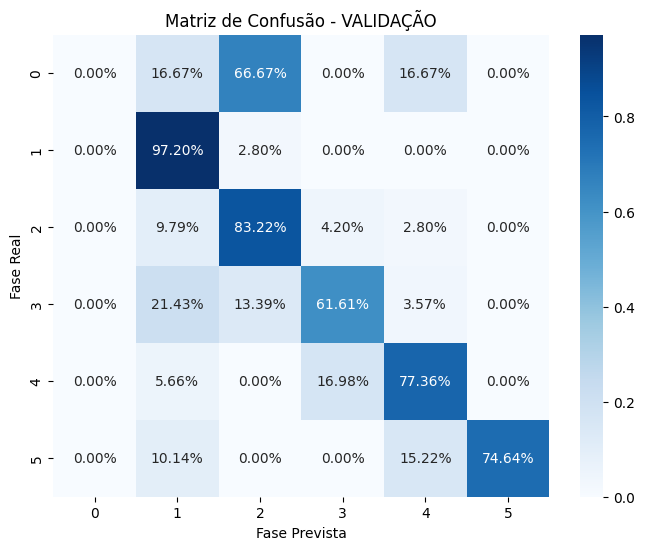

In [ ]:

# --- 7. Plotagem das Matrizes de Confusão ---
def plotar_matriz_porcentagem(y_true, y_pred, titulo):
    conf_matrix = confusion_matrix(y_true, y_pred)
    # Normaliza pelas linhas para gerar a porcentagem de acertos/erros [cite: 2534]
    conf_matrix_pct = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix_pct, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names_str, yticklabels=class_names_str)
    plt.title(titulo)
    plt.ylabel('Fase Real')
    plt.xlabel('Fase Prevista')
    plt.show()

# Plota as duas matrizes solicitadas
plotar_matriz_porcentagem(y_val, y_val_pred, 'Matriz de Confusão - VALIDAÇÃO')

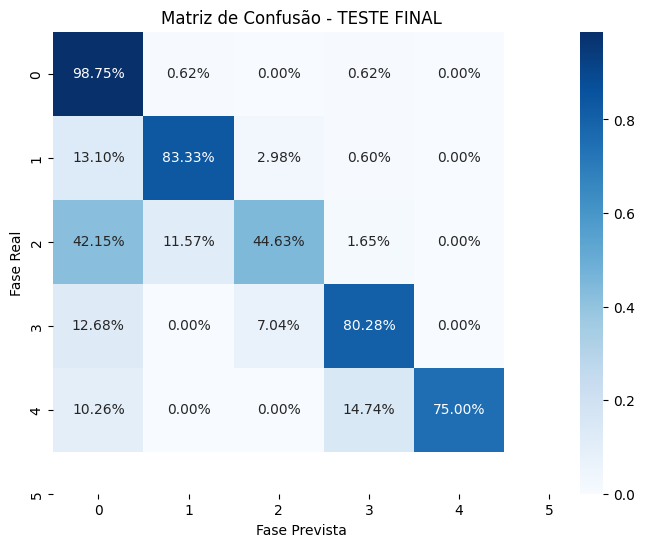

In [ ]:

plotar_matriz_porcentagem(y_test, y_test_pred, 'Matriz de Confusão - TESTE FINAL')

## CONVERT FILES

In [ ]:
pip install micromlgen

In [ ]:
import joblib
from micromlgen import port

# Carregue o modelo Random Forest que você já treinou
try:
    model = joblib.load('/content/drive/MyDrive/Faculdade/IC/Códigos/modelF_xgboost.pkl')
    print("✅ Modelo 'modelo_randomforest.pkl' carregado com sucesso.")
except FileNotFoundError:
    print("❌ ERRO: Arquivo 'modelo_randomforest.pkl' não encontrado.")
    print("Certifique-se de que o modelo treinado está na mesma pasta.")
    exit()

# O número de features que seu modelo espera
# (24 eixos * 7 estatísticas = 168 features)
num_features = 42
X_placeholder = [[0] * num_features] # Cria um placeholder com o formato correto

# Converte o modelo para código C e salva em um arquivo .h
# O nome da classe gerada será 'RandomForest'
try:
    with open('/content/drive/MyDrive/Faculdade/IC/Resultados Pi/modelos/modelx_F10.h', 'w') as f:
        f.write(port(model, classname='RandomForest', X=X_placeholder))
    print("✅ Modelo convertido para 'modelo_rf.h' com sucesso!")
    print("Agora você pode compilar seu código C com este arquivo.")
except Exception as e:
    print(f"❌ ERRO ao converter o modelo: {e}")


✅ Modelo 'modelo_randomforest.pkl' carregado com sucesso.
✅ Modelo convertido para 'modelo_rf.h' com sucesso!
Agora você pode compilar seu código C com este arquivo.


## teste do chat


###funções

In [16]:
import pandas as pd
import numpy as np
import joblib

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# =========================
# CONFIGURAÇÕES
# =========================

import numpy as np
import pandas as pd
import math

# Essa classe imita EXATAMENTE a sua classe 'Kalman' do C++
class SimpleKalman:
    def __init__(self, process_noise, sensor_noise, estimated_error, initial_value):
        self.Q = process_noise
        self.R = sensor_noise
        self.P = estimated_error
        self.x = initial_value

    def update(self, measurement):
        # 1. Predição
        self.P = self.P + self.Q
        # 2. Correção
        K = self.P / (self.P + self.R)
        self.x = self.x + K * (measurement - self.x)
        self.P = (1 - K) * self.P
        return self.x

# Inicializa os filtros para Roll e Pitch
# (Você pode ajustar 0.01 e 0.1 para ficarem iguais aos valores de Q e R do seu C++)

WINDOW_SIZE = 30
STEP = 5

FEATURE_COLS = [
    'ax', 'ay', 'az',
    'gx', 'gy', 'gz',
    'roll', 'pitch'
]

LABEL_COL = 'Fase'

arquivos_treino = [
   '/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_felix1_rot.csv',
   '/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_sah1_rot.csv',
   '/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_cell1_rot.csv',
   '/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_cell1.5_rot.csv',
   '/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_sah2_rot.csv'
]

arquivo_teste = '/content/drive/MyDrive/Faculdade/IC/Resultados Pi/rotulados_testes/log_felix0_rot.csv'


# =========================
# FUNÇÃO DE FEATURES
# =========================

def extrair_features_janelas(df, window_size=30, step=5):
    X = []
    y = []

    df = df.reset_index(drop=True)
    del df['classe_prevista']

    df['Fase'] = df['Fase'].replace({
      'Heel-strike': 1,
      'Foot-flat': 2,
      'Heel-off': 3,
      'Toe-off': 4,
      'Swing': 5,
      'Desconhecida': 0
      })


    kalman_roll = SimpleKalman(0.01, 0.1, 1.0, 0.0)
    kalman_pitch = SimpleKalman(0.01, 0.1, 1.0, 0.0)

    roll_list = []
    pitch_list = []

    print("Calculando Roll e Pitch com o seu Filtro de Kalman...")

    for i in range(len(df)):
        ax = df['ax'].iloc[i]
        ay = df['ay'].iloc[i]
        az = df['az'].iloc[i]

        # 1. Calcula o ângulo bruto usando apenas o Acelerômetro (Trigonometria básica)
        raw_roll = math.degrees(math.atan2(ay, az))
        raw_pitch = math.degrees(math.atan2(-ax, math.sqrt(ay**2 + az**2)))

        # 2. Passa os ângulos brutos pelo Filtro de Kalman
        filtered_roll = kalman_roll.update(raw_roll)
        filtered_pitch = kalman_pitch.update(raw_pitch)

        roll_list.append(filtered_roll)
        pitch_list.append(filtered_pitch)

    # Adiciona as novas colunas filtradas ao seu DataFrame
    df['roll'] = roll_list
    df['pitch'] = pitch_list

    for i in range(0, len(df) - window_size + 1, step):
        janela = df.iloc[i:i + window_size]

        features = []

        for col in FEATURE_COLS:
           signal = janela[col].values # .values converte para numpy array (mais fácil de pegar index)

           # Tem que ser EXATAMENTE a mesma ordem do C++
           features.append(signal.mean())        # 0: Mean
           features.append(signal.std(ddof=0))   # 1: StdDev (ddof=0 imita a divisão por N do seu C++)
           features.append(signal[0])            # 2: Front
           features.append(signal[-1])           # 3: Back
           features.append(signal.min())         # 4: Min
           features.append(signal.max())         # 5: Max
           features.append(signal[-1] - signal[0]) # 6: Range (Back - Front)

        # Label da janela = label do último ponto da janela
        label = janela[LABEL_COL].iloc[-1]

        X.append(features)
        y.append(label)
    print(f"Features calculadas {i}")

    return np.array(X), np.array(y)



###treino

In [17]:
class_weights_manual = {
    0: 3.0,
    1: 1.5,
    2: 0.5,
    3: 3.0,
    4: 4.0,
    5: 1.5
}
# =========================
# CARREGAR TREINO
# =========================

X_train_lista = []
y_train_lista = []

for arq in arquivos_treino:
    df = pd.read_csv(arq)

    X_arq, y_arq = extrair_features_janelas(df, WINDOW_SIZE, STEP)

    X_train_lista.append(X_arq)
    y_train_lista.append(y_arq)

X_train = np.vstack(X_train_lista)
y_train = np.concatenate(y_train_lista)


# =========================
# CARREGAR TESTE OFFLINE
# =========================

df_teste = pd.read_csv(arquivo_teste)

X_test, y_test = extrair_features_janelas(df_teste, WINDOW_SIZE, STEP)


# =========================
# CODIFICAR LABELS
# =========================

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Classes:", le.classes_)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


# =========================
# NORMALIZAÇÃO
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================
# TREINAR MODELO
# =========================

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train_scaled, y_train_enc)


# =========================
# TESTE OFFLINE NA CAMINHADA NOVA
# =========================

y_pred_enc = model.predict(X_test_scaled)

print(classification_report(
    y_test_enc,
    y_pred_enc,
    target_names=[str(c) for c in le.classes_]
))


Calculando Roll e Pitch com o seu Filtro de Kalman...
Features calculadas 2540
Calculando Roll e Pitch com o seu Filtro de Kalman...
Features calculadas 6200
Calculando Roll e Pitch com o seu Filtro de Kalman...
Features calculadas 4800
Calculando Roll e Pitch com o seu Filtro de Kalman...
Features calculadas 5080
Calculando Roll e Pitch com o seu Filtro de Kalman...
Features calculadas 7160
Calculando Roll e Pitch com o seu Filtro de Kalman...
Features calculadas 2210
Classes: ['0' '1' '2' '3' '4' '5']
X_train: (5161, 56)
X_test: (443, 56)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        71
           1       0.88      0.41      0.56        71
           2       0.33      0.97      0.50       126
           3       0.50      0.04      0.07        50
           4       0.00      0.00      0.00        54
           5       0.91      0.42      0.58        71

    accuracy                           0.41       443
   macro avg       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###plot

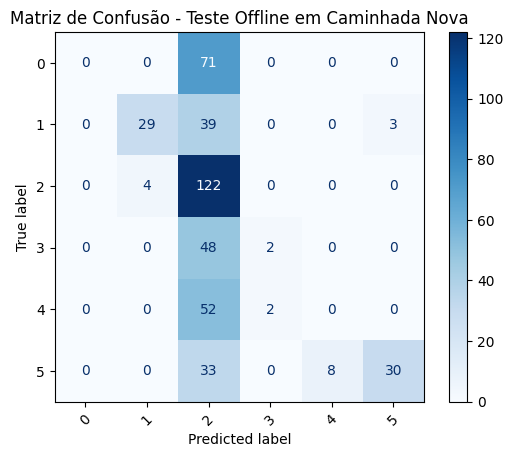

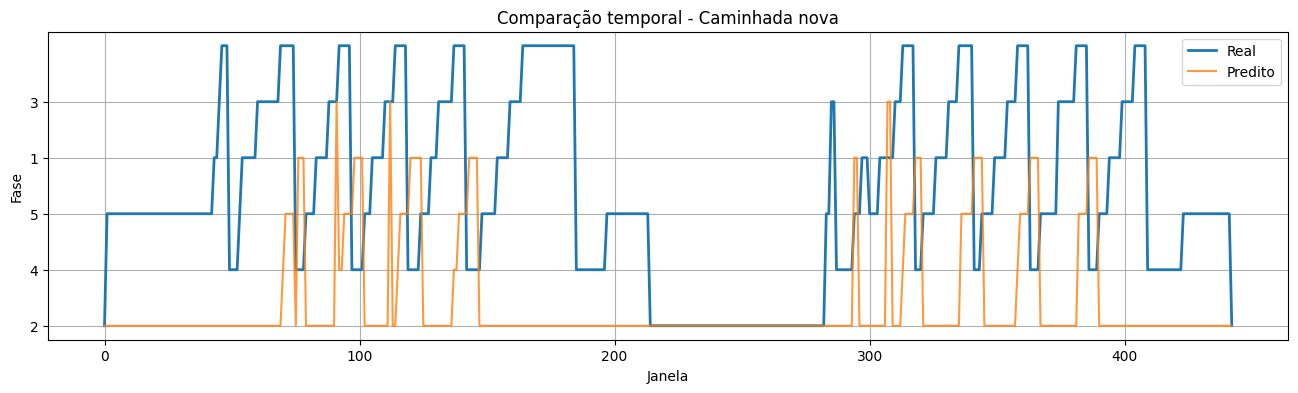

In [18]:

cm = confusion_matrix(y_test_enc, y_pred_enc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusão - Teste Offline em Caminhada Nova")
plt.show()
# =========================
# PLOT TEMPORAL
# =========================

y_pred = le.inverse_transform(y_pred_enc)

plt.figure(figsize=(16, 4))
plt.plot(y_test, label='Real', linewidth=2)
plt.plot(y_pred, label='Predito', alpha=0.8)
plt.xlabel("Janela")
plt.ylabel("Fase")
plt.title("Comparação temporal - Caminhada nova")
plt.legend()
plt.grid()
plt.show()


###save

In [ ]:
# =========================
# SALVAR MODELO
# =========================

joblib.dump(model, 'modelo_xgboost_offline.pkl')
joblib.dump(scaler, 'scaler_offline.pkl')
joblib.dump(le, 'label_encoder_offline.pkl')

print("Modelo, scaler e label encoder salvos.")